# LLM Healthcare Tutorial: Diabetes Risk Prediction Using Claude on Amazon Bedrock

This tutorial demonstrates applying LLMs to healthcare using synthetic patient data (Synthea).

We explore multiple prompting strategies:
1. Zero-shot prompting
2. Few-shot in-context learning
3. Chain-of-thought reasoning
4. Medical record summarization

**Dataset**: Synthea synthetic patient data (100 patients)

**Task**: Predict diabetes risk from patient demographics, conditions, observations, and medications

**Model**: Claude (Anthropic) via Amazon Bedrock

## Section 1: Setup and Data Loading

In [1]:
import boto3
import json
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
bedrock = boto3.client('bedrock-runtime', region_name='us-east-1')

def call_claude(messages, system=None, model_id='us.anthropic.claude-sonnet-4-6', max_tokens=1024):
    body = {
        'anthropic_version': 'bedrock-2023-05-31',
        'messages': messages,
        'max_tokens': max_tokens
    }
    if system:
        body['system'] = system
    response = bedrock.invoke_model(modelId=model_id, body=json.dumps(body))
    result = json.loads(response['body'].read())
    return result['content'][0]['text']

### Load Synthea Data

In [3]:
DATA_DIR = 'synthea_sample_data_csv_latest'

patients = pd.read_csv(f'{DATA_DIR}/patients.csv')
conditions = pd.read_csv(f'{DATA_DIR}/conditions.csv')
observations = pd.read_csv(f'{DATA_DIR}/observations.csv')
medications = pd.read_csv(f'{DATA_DIR}/medications.csv')

print(f'Patients: {len(patients)}')
print(f'Conditions: {len(conditions)}')
print(f'Observations: {len(observations)}')
print(f'Medications: {len(medications)}')

Patients: 117
Conditions: 4023
Observations: 86634
Medications: 5860


### Build Patient Profiles with Diabetes Labels

We label patients as diabetic/prediabetic (positive) or not (negative), then build a text profile for each patient from their records.

In [4]:
# Identify diabetes-related patients
diabetes_keywords = ['diabetes', 'prediabetes']
diabetes_patients = conditions[conditions['DESCRIPTION'].str.lower().str.contains('|'.join(diabetes_keywords), na=False)]['PATIENT'].unique()
patients['diabetes_label'] = patients['Id'].isin(diabetes_patients).astype(int)

print(f'Diabetic/Prediabetic patients: {patients["diabetes_label"].sum()}')
print(f'Non-diabetic patients: {(patients["diabetes_label"] == 0).sum()}')

Diabetic/Prediabetic patients: 59
Non-diabetic patients: 58


In [5]:
def build_patient_profile(patient_id):
    """Build a text summary of a patient from their records (excluding diabetes-related info)."""
    p = patients[patients['Id'] == patient_id].iloc[0]
    
    # Demographics
    age = 2024 - int(p['BIRTHDATE'][:4])
    gender = 'Male' if p['GENDER'] == 'M' else 'Female'
    race = p['RACE']
    
    # Conditions (exclude diabetes-related ones to avoid data leakage)
    pt_conditions = conditions[conditions['PATIENT'] == patient_id]['DESCRIPTION'].unique()
    pt_conditions = [c for c in pt_conditions if not any(kw in c.lower() for kw in diabetes_keywords)]
    cond_str = ', '.join(pt_conditions[:10]) if len(pt_conditions) > 0 else 'None recorded'
    
    # Key observations (BMI, blood pressure, glucose)
    pt_obs = observations[observations['PATIENT'] == patient_id]
    obs_items = []
    for desc in ['Body Mass Index', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 
                 'Glucose', 'Hemoglobin A1c/Hemoglobin.total in Blood']:
        vals = pt_obs[pt_obs['DESCRIPTION'].str.contains(desc, na=False)]['VALUE']
        if len(vals) > 0:
            try:
                latest = float(vals.iloc[-1])
                obs_items.append(f'{desc}: {latest:.1f}')
            except (ValueError, TypeError):
                pass
    obs_str = ', '.join(obs_items) if obs_items else 'No key observations'
    
    # Medications (exclude diabetes meds)
    pt_meds = medications[medications['PATIENT'] == patient_id]['DESCRIPTION'].unique()
    pt_meds = [m for m in pt_meds if not any(kw in m.lower() for kw in ['metformin', 'insulin', 'glipizide'])]
    med_str = ', '.join(pt_meds[:8]) if len(pt_meds) > 0 else 'None'
    
    profile = f"""Patient: {age} year old {gender}, Race: {race}
Conditions: {cond_str}
Observations: {obs_str}
Medications: {med_str}"""
    return profile

# Build profiles for all patients
patients['profile'] = patients['Id'].apply(build_patient_profile)
print('Example patient profile:')
print(patients.iloc[0]['profile'])

Example patient profile:
Patient: 35 year old Male, Race: white
Conditions: Housing unsatisfactory (finding), Received higher education (finding), Loss of teeth (disorder), Full-time employment (finding), Acute bronchitis (disorder), Medication review due (situation), Unemployed (finding), Viral sinusitis (disorder), Reports of violence in the environment (finding), Stress (finding)
Observations: Systolic Blood Pressure: 88.0, Diastolic Blood Pressure: 78.0
Medications: Acetaminophen 325 MG Oral Tablet, Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet, sodium fluoride 0.0272 MG/MG Oral Gel


### Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(patients, test_size=0.25, random_state=42, stratify=patients['diabetes_label'])
print(f'Train: {len(train_df)} (diabetic: {train_df["diabetes_label"].sum()})')
print(f'Test: {len(test_df)} (diabetic: {test_df["diabetes_label"].sum()})')

Train: 87 (diabetic: 44)
Test: 30 (diabetic: 15)


## Section 2: Zero-Shot Prompting

Ask Claude to predict diabetes risk with no examples — just the patient profile and a question.

In [7]:
def zero_shot_predict(profile):
    prompt = f"""Based on the following patient record, predict whether this patient is at risk for diabetes or prediabetes.
Answer with exactly one word: Positive or Negative.

{profile}

Prediction:"""
    resp = call_claude(
        messages=[{'role': 'user', 'content': prompt}],
        model_id='us.anthropic.claude-haiku-4-5-20251001-v1:0',
        max_tokens=5
    )
    return 1 if 'positive' in resp.lower() else 0

# Test on one patient first
sample = test_df.iloc[0]
print('Profile:', sample['profile'])
print('True label:', sample['diabetes_label'])
print('Prediction:', zero_shot_predict(sample['profile']))

Profile: Patient: 50 year old Female, Race: white
Conditions: Impacted molars (disorder), Chronic intractable migraine without aura (disorder), Chronic pain (finding), Housing unsatisfactory (finding), Only received primary school education (finding), Dependent drug abuse (disorder), Social isolation (finding), Body mass index 30+ - obesity (finding), Limited social contact (finding), Chronic sinusitis (disorder)
Observations: Systolic Blood Pressure: 112.0, Diastolic Blood Pressure: 68.0
Medications: {7 (ethinyl estradiol 0.01 MG Oral Tablet) / 84 (ethinyl estradiol 0.03 MG / levonorgestrel 0.15 MG Oral Tablet) } Pack [Seasonique], {24 (drospirenone 3 MG / ethinyl estradiol 0.02 MG Oral Tablet) / 4 (inert ingredients 1 MG Oral Tablet) } Pack [Yaz 28 Day], 1 ML medroxyprogesterone acetate 150 MG/ML Injection, Vitamin B12 5 MG/ML Injectable Solution, Cisplatin 50 MG Injection, PACLitaxel 100 MG Injection, 1 ML medroxyPROGESTERone acetate 150 MG/ML Injection, Naproxen sodium 220 MG Oral 

In [8]:
# Run zero-shot on all test patients
zeroshot_preds = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    pred = zero_shot_predict(row['profile'])
    zeroshot_preds.append(pred)
    time.sleep(0.5)

zeroshot_labels = list(test_df['diabetes_label'])
print('\nZero-Shot Results:')
print(classification_report(zeroshot_labels, zeroshot_preds, target_names=['No Diabetes', 'Diabetes']))

100%|██████████| 30/30 [01:09<00:00,  2.30s/it]


Zero-Shot Results:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.40      0.55        15
    Diabetes       0.61      0.93      0.74        15

    accuracy                           0.67        30
   macro avg       0.73      0.67      0.64        30
weighted avg       0.73      0.67      0.64        30



## Section 3: Few-Shot In-Context Learning

Provide Claude with a few labeled examples before asking it to predict. This helps the model understand the task pattern.

In [9]:
# Select few-shot examples from training set (2 positive, 2 negative)
pos_examples = train_df[train_df['diabetes_label'] == 1].head(2)
neg_examples = train_df[train_df['diabetes_label'] == 0].head(2)

few_shot_text = ""
for _, row in pd.concat([pos_examples, neg_examples]).iterrows():
    label = 'Positive' if row['diabetes_label'] == 1 else 'Negative'
    few_shot_text += f"""
---
{row['profile']}
Diabetes Risk: {label}
"""

print('Few-shot examples built:', few_shot_text[:500], '...')

Few-shot examples built: 
---
Patient: 61 year old Male, Race: white
Conditions: Housing unsatisfactory (finding), Received higher education (finding), Body mass index 30+ - obesity (finding), Has a criminal record (finding), Full-time employment (finding), Anemia (disorder), Stress (finding), Medication review due (situation), Viral sinusitis (disorder), Sleep disorder (disorder)
Observations: Systolic Blood Pressure: 119.0, Diastolic Blood Pressure: 78.0, Glucose: 99.2, Hemoglobin A1c/Hemoglobin.total in Blood: 3.3
Me ...


In [10]:
def few_shot_predict(profile):
    prompt = f"""You are predicting diabetes risk from patient records. Here are some examples:
{few_shot_text}
---
Now predict for this patient. Answer with exactly one word: Positive or Negative.

{profile}
Diabetes Risk:"""
    resp = call_claude(
        messages=[{'role': 'user', 'content': prompt}],
        model_id='us.anthropic.claude-haiku-4-5-20251001-v1:0',
        max_tokens=5
    )
    return 1 if 'positive' in resp.lower() else 0

# Run few-shot on all test patients
fewshot_preds = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    pred = few_shot_predict(row['profile'])
    fewshot_preds.append(pred)
    time.sleep(0.5)

print('\nFew-Shot Results:')
print(classification_report(zeroshot_labels, fewshot_preds, target_names=['No Diabetes', 'Diabetes']))

100%|██████████| 30/30 [00:48<00:00,  1.61s/it]


Few-Shot Results:
              precision    recall  f1-score   support

 No Diabetes       1.00      0.67      0.80        15
    Diabetes       0.75      1.00      0.86        15

    accuracy                           0.83        30
   macro avg       0.88      0.83      0.83        30
weighted avg       0.88      0.83      0.83        30



## Section 4: Chain-of-Thought Reasoning

Ask Claude to reason step-by-step before making a prediction. This often improves accuracy on complex tasks.

In [11]:
def cot_predict(profile):
    prompt = f"""Analyze this patient record step by step to assess diabetes risk.

{profile}

Think through the following:
Step 1: What demographic risk factors are present (age, gender, race)?
Step 2: What conditions suggest metabolic risk (obesity, hypertension, etc.)?
Step 3: What do the lab values indicate (BMI, glucose, blood pressure)?
Step 4: Do the medications suggest any related conditions?

Based on your analysis, is this patient at risk for diabetes?
End your response with exactly: PREDICTION: Positive or PREDICTION: Negative"""
    resp = call_claude(
        messages=[{'role': 'user', 'content': prompt}],
        system='You are a clinical decision support system. Analyze patient data carefully.',
        model_id='us.anthropic.claude-haiku-4-5-20251001-v1:0',
        max_tokens=500
    )
    return resp, 1 if 'prediction: positive' in resp.lower() else 0

# Show one example with full reasoning
sample = test_df.iloc[0]
reasoning, pred = cot_predict(sample['profile'])
print('Reasoning:')
print(reasoning)
print(f'\nTrue label: {sample["diabetes_label"]}, Predicted: {pred}')

Reasoning:
# Diabetes Risk Assessment - Step by Step Analysis

## Step 1: Demographic Risk Factors
- **Age:** 50 years old (postmenopausal/perimenopausal range - increased diabetes risk)
- **Gender:** Female (postmenopausal women have increased diabetes risk)
- **Race:** White (lower baseline diabetes risk compared to some populations, but not protective)

**Assessment:** Moderate demographic risk due to age and menopausal status.

## Step 2: Conditions Suggesting Metabolic Risk
- **Obesity (BMI 30+):** Major independent risk factor for type 2 diabetes
- **Hypertension status:** Blood pressure 112/68 is currently normal-to-optimal (not elevated)
- **Chronic conditions:** Migraines, chronic pain, and sinusitis are not directly metabolic but may indicate chronic inflammatory state
- **Psychosocial factors:** Drug abuse, social isolation, inadequate housing, limited education - these are associated with poor health outcomes and reduced diabetes management capacity

**Assessment:** Signifi

In [12]:
# Run CoT on all test patients
cot_preds = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    _, pred = cot_predict(row['profile'])
    cot_preds.append(pred)
    time.sleep(0.5)

print('\nChain-of-Thought Results:')
print(classification_report(zeroshot_labels, cot_preds, target_names=['No Diabetes', 'Diabetes']))

100%|██████████| 30/30 [02:48<00:00,  5.62s/it]


Chain-of-Thought Results:
              precision    recall  f1-score   support

 No Diabetes       0.48      0.93      0.64        15
    Diabetes       0.00      0.00      0.00        15

    accuracy                           0.47        30
   macro avg       0.24      0.47      0.32        30
weighted avg       0.24      0.47      0.32        30



## Section 5: Medical Record Summarization

Demonstrate Claude's ability to summarize complex medical records into plain language for different audiences.

In [13]:
sample_profile = test_df.iloc[0]['profile']

# Summarize for a doctor
doctor_summary = call_claude(
    system='You are a medical assistant.',
    messages=[{'role': 'user', 'content': f'Summarize this patient record in 3 sentences for a physician:\n\n{sample_profile}'}],
    model_id='us.anthropic.claude-haiku-4-5-20251001-v1:0'
)
print('=== Summary for Doctor ===')
print(doctor_summary)

print()

# Summarize for the patient (plain language)
patient_summary = call_claude(
    system='You are a friendly health educator. Use simple, non-technical language.',
    messages=[{'role': 'user', 'content': f'Explain this medical record to the patient in simple terms (3 sentences):\n\n{sample_profile}'}],
    model_id='us.anthropic.claude-haiku-4-5-20251001-v1:0'
)
print('=== Summary for Patient ===')
print(patient_summary)

=== Summary for Doctor ===
# Patient Summary

This 50-year-old white female presents with multiple chronic conditions including chronic intractable migraine, chronic pain, chronic sinusitis, and impacted molars, complicated by dependent drug abuse and significant psychosocial stressors including housing instability and social isolation. She has comorbid obesity (BMI 30+) and limited education, with vital signs currently stable (BP 112/68). Her medication regimen includes hormonal contraceptives, B12 supplementation, chemotherapy agents (cisplatin and paclitaxel), medroxyprogesterone, and NSAIDs, suggesting either active malignancy treatment or recent oncologic history.

=== Summary for Patient ===
# Your Health Summary in Simple Terms

You have several things we're managing for your health right now. You experience frequent, severe headaches and ongoing pain, and you're dealing with some dental issues (wisdom teeth problems) and sinus infections that keep coming back. You're also takin

## Section 6: Evaluation and Comparison

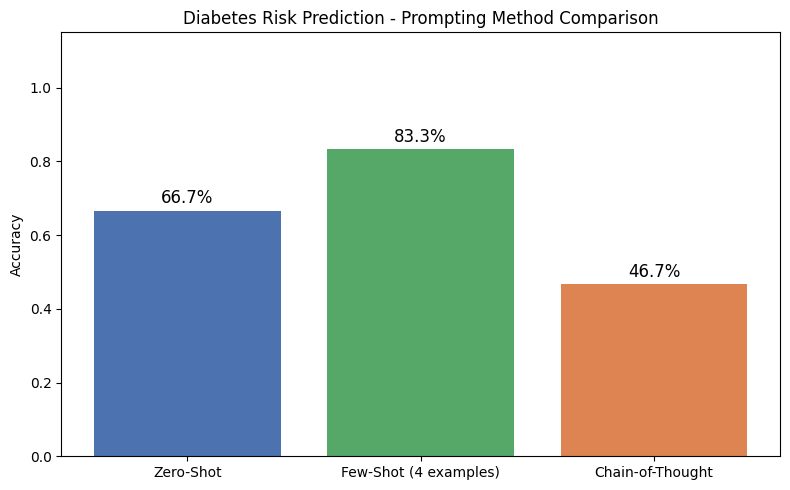

In [14]:
# Compute accuracy for each method
zs_acc = accuracy_score(zeroshot_labels, zeroshot_preds)
fs_acc = accuracy_score(zeroshot_labels, fewshot_preds)
cot_acc = accuracy_score(zeroshot_labels, cot_preds)

methods = ['Zero-Shot', 'Few-Shot (4 examples)', 'Chain-of-Thought']
accuracies = [zs_acc, fs_acc, cot_acc]

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#55a868', '#DD8452']
bars = ax.bar(methods, accuracies, color=colors)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.1%}', ha='center', fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_title('Diabetes Risk Prediction - Prompting Method Comparison')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

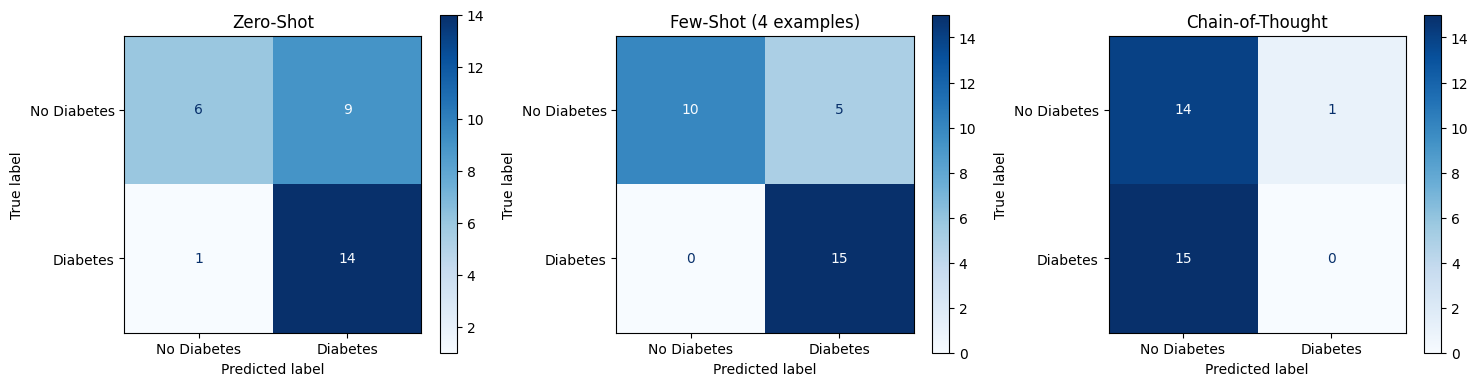

In [15]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, preds, title in zip(axes, [zeroshot_preds, fewshot_preds, cot_preds], methods):
    cm = confusion_matrix(zeroshot_labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [16]:
# Summary table
summary = pd.DataFrame({
    'Method': methods,
    'Accuracy': [f'{a:.1%}' for a in accuracies],
    'Description': [
        'Direct prediction with no examples',
        '4 labeled examples provided in prompt',
        'Step-by-step reasoning before prediction'
    ]
})
summary

,Method,Accuracy,Description
0,Zero-Shot,66.7%,Direct prediction with no examples
1,Few-Shot (4 examples),83.3%,4 labeled examples provided in prompt
2,Chain-of-Thought,46.7%,Step-by-step reasoning before prediction


## Section 7: Ideas for Improvement

1. **More few-shot examples**: Increase from 4 to 8-10 examples for better in-context learning
2. **Fine-tuning**: Use a domain-specific model like PMC-LLaMA for better medical understanding
3. **Richer patient profiles**: Include lab trends over time, family history, lifestyle factors
4. **Ensemble methods**: Combine predictions from multiple prompting strategies
5. **Embedding-based approach**: Use Titan embeddings + classifier (as shown in Bedrock_Claude_API notebook) for potentially higher accuracy
6. **Tree-of-Thought**: Explore multiple reasoning paths and pick the most consistent prediction